# 별점 및 리뷰 처리 방법

## 1. 별점 처리

In [12]:
import pandas as pd

df_naver = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\seoul_cafes(리뷰수, 별점).csv')
df_kakao = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\kakaoID_카페_상권_매칭_with_ratings_완료.csv')

df_kakao = df_kakao[['상가업소번호','상호명','지점명','별점','후기 수']]
df_kakao.rename(columns={'별점':'kakao_score', '후기 수':'kakao_reviewCount'}, inplace=True)
df_naver.rename(columns={'query':'상호명', 'score':'naver_score', 'reviewCount':'naver_reviewCount'},inplace=True)
df_naver = df_naver[['상호명', 'naver_score', 'naver_reviewCount']]

# 상호명 문제 있는 부분
"""
      상가업소번호              상호명  kakao_score  kakao_review found_name  \
161      NaN            ㅤㄷㅛㅎ다          NaN           NaN        NaN   
162      NaN            ㅤㄷㅣㅍ다          NaN           NaN    DEEP DA   
163      NaN          ㅤㅁㅗㅋ커피점          NaN           NaN        NaN   
164      NaN       ㅤㅂㅓㅍ커피로스터스          NaN           NaN    벞커피로스터스   
165      NaN           ㅤㅅㅑㅍ카페          NaN           NaN        샾카페   
166      NaN           ㅤㅊㅔㅋ커피          NaN           NaN        쳌커피   
167      NaN             ㅤㅋㅓㅍ          NaN           NaN       컾 본점   
168      NaN          ㅤㅍㅓㅋ스커피          NaN           NaN       펔스커피   
637      NaN     과일ㅤㅅㅑㅍcafe리치          NaN           NaN        NaN   
1110     NaN  나따오비까WITH커피ㅤㅅㅑㅍ          NaN           NaN        NaN   
2712     NaN       딱따구리커피ㅤㅅㅑㅍ          NaN           NaN        NaN   
3692     NaN           매니ㅤㅇㅏㅋ          NaN           NaN      커피매니앜   
6311     NaN            빈ㅤㅋㅓㅍ          NaN           NaN        NaN   
6801     NaN           삼원ㅤㅅㅔㄷ          NaN           NaN        NaN   
12379    NaN           카페ㅤㅎㅣㅎ          NaN           NaN        카페힣   
12677    NaN         카페라ㅤㅇㅣㅋ유          NaN           NaN      카페라잌유   
14699    NaN         커피엉클ㅤㅅㅑㅍ          NaN           NaN        NaN 
"""

'\n      상가업소번호              상호명  kakao_score  kakao_review found_name  161      NaN            ㅤㄷㅛㅎ다          NaN           NaN        NaN   \n162      NaN            ㅤㄷㅣㅍ다          NaN           NaN    DEEP DA   \n163      NaN          ㅤㅁㅗㅋ커피점          NaN           NaN        NaN   \n164      NaN       ㅤㅂㅓㅍ커피로스터스          NaN           NaN    벞커피로스터스   \n165      NaN           ㅤㅅㅑㅍ카페          NaN           NaN        샾카페   \n166      NaN           ㅤㅊㅔㅋ커피          NaN           NaN        쳌커피   \n167      NaN             ㅤㅋㅓㅍ          NaN           NaN       컾 본점   \n168      NaN          ㅤㅍㅓㅋ스커피          NaN           NaN       펔스커피   \n637      NaN     과일ㅤㅅㅑㅍcafe리치          NaN           NaN        NaN   \n1110     NaN  나따오비까WITH커피ㅤㅅㅑㅍ          NaN           NaN        NaN   \n2712     NaN       딱따구리커피ㅤㅅㅑㅍ          NaN           NaN        NaN   \n3692     NaN           매니ㅤㅇㅏㅋ          NaN           NaN      커피매니앜   \n6311     NaN            빈ㅤㅋㅓㅍ          NaN           NaN        

In [13]:
df_naver.loc[9081,'상호명'] = '둏다'
df_naver.loc[12980,'상호명'] = '딮다'
df_naver.loc[360, '상호명'] = '뫀커피점'
df_naver.loc[3417,'상호명'] = '벞커피로스터스'
df_naver.loc[9312,'상호명'] = '샾카페'
df_naver.loc[11613,'상호명'] = '쳌커피'
df_naver.loc[6149, '상호명'] = '컾'
df_naver.loc[7399,'상호명'] = '펔스커피'
df_naver.loc[13102,'상호명'] = '과일샾cafe리치'
df_naver.loc[5644,'상호명'] = '나따오비까WITH커피샾'
df_naver.loc[2006, '상호명'] = '딱따구리커피샾'
df_naver.loc[12045,'상호명'] = '매니앜'
df_naver.loc[1266, '상호명'] = '빈컾'
df_naver.loc[1876, '상호명'] = '삼원섿'
df_naver.loc[5737, '상호명'] = '카페힣'
df_naver.loc[9536, '상호명'] = '카페라잌유'
df_naver.loc[6480,'상호명'] = '커피엉클샾'

1. 네이버: Index(['query', 'found_name', 'score', 'reviewCount'], dtype='object')
2. 카카오: Index(['상가업소번호', '상호명', '지점명', 'TRDAR_CD', 'TRDAR_CD_N', '도로명주소', '위도', '경도',
       '지번주소', '신우편번호', '카카오맵ID', '별점', '후기 수'],
      dtype='object')
- 'query' = '상호명'
- 'score' = '별점'
- 'reviewCount' = '후기 수'

In [15]:
# 1. 네이버와 카카오 데이터 병합 (상호명 기준으로)
df_merged = pd.merge(df_kakao, df_naver, on='상호명', how='outer')

print(len(df_merged))
df_merged.head(2)
df_merged.to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_별점리뷰통합.csv', encoding = 'utf-8-sig', index = False)

18273


In [24]:
# 2. 결측치 처리: 평점이 없는 경우 0으로 처리
import pandas as pd
df_merged = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_별점리뷰통합.csv')
df_merged['naver_score'] = df_merged['naver_score'].fillna(0)
df_merged['kakao_score'] = df_merged['kakao_score'].fillna(0)

# 3. 평균 평점 계산
def get_avg_rating(kakao, naver):
    if kakao > 0 and naver > 0:
        return (kakao + naver) / 2
    elif kakao > 0:
        return kakao
    elif naver > 0:
        return naver
    else:
        return 0

df_merged['avg_score'] = df_merged.apply(lambda row: get_avg_rating(row['kakao_score'], row['naver_score']), axis=1)

df_merged['avg_score'].head(10)

df_merged.rename(columns={'avg_score':'rating_score'}, inplace=True)

df_rating = df_merged[['상가업소번호', 'rating_score']]
df_rating.head(2), df_rating.columns

(                 상가업소번호  rating_score
 0  MA010120220806361295           0.0
 1  MA0101202406A0096622           5.0,
 Index(['상가업소번호', 'rating_score'], dtype='object'))

In [5]:
import pandas as pd
df_score = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0502.csv')
#print(len(df_score))
df_scores = pd.merge(df_score, df_rating, on='상가업소번호', how='left')
print(df_scores.columns.tolist())
df_scores.head(2)

['상가업소번호', 'period_score', 'rating_score']


,상가업소번호,period_score,rating_score
0,MA010120220800000033,5,0.000
1,MA010120220800000302,5,4.225


In [6]:
df_scores.to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_점수_0502.csv', encoding='utf-8-sig',index = False)

## 리뷰 처리

### 리뷰 데이터 처리 가능 방법
- 둘의 리뷰 수를 합침 (Nan이면 한쪽만) 
1. z-score
2. minMax regulation

In [8]:
import pandas as pd
df_review = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_별점리뷰통합.csv')
df_review
df_review = df_review[df_review['상가업소번호'].isin(df_score['상가업소번호'])]

In [9]:
df_review['naver_reviewCount'] = pd.to_numeric(df_review['naver_reviewCount'], errors='coerce')
df_review['kakao_reviewCount'] = pd.to_numeric(df_review['kakao_reviewCount'], errors='coerce')

df_review['sum_reviewCount'] = df_review[['naver_reviewCount', 'kakao_reviewCount']].sum(axis=1, skipna=True)

print("최소값:", df_review['sum_reviewCount'].min())
print("최대값:", df_review['sum_reviewCount'].max())
print("평균:", df_review['sum_reviewCount'].mean())
print("중앙값:", df_review['sum_reviewCount'].median())
print("표준편차:", df_review['sum_reviewCount'].std())


최소값: 0.0
최대값: 2438.0
평균: 76.60238842111056
중앙값: 19.0
표준편차: 149.1330256605544


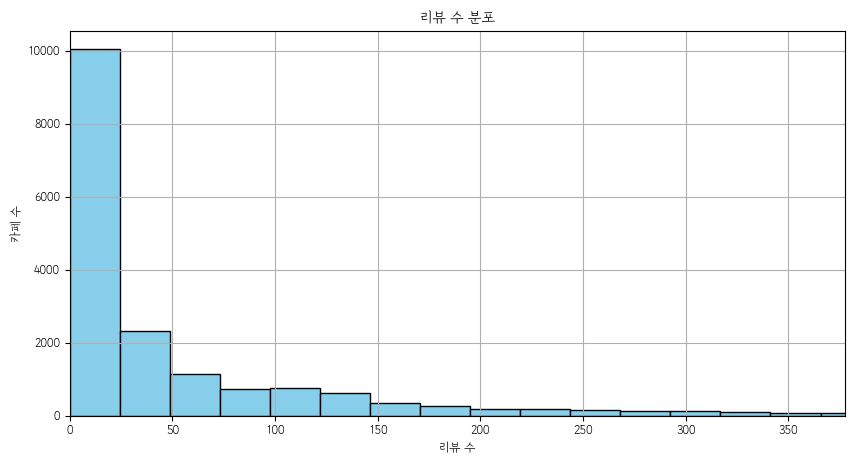

In [10]:
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm, rc

font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_prop = fm.FontProperties(fname=font_path)
rc('font', family=font_prop.get_name())

plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10,5))
plt.hist(df_review['sum_reviewCount'], bins=100, color='skyblue', edgecolor='black')
plt.title('리뷰 수 분포')
plt.xlabel('리뷰 수')
plt.ylabel('카페 수')
plt.xlim(0, df_review['sum_reviewCount'].quantile(0.95))  # 극단값 제외하면 더 보기 쉬움
plt.grid(True)
plt.show()


In [17]:
# 최대최소 정규화
import numpy as np

x = df_review['sum_reviewCount'].to_numpy()
x_min = np.nanmin(x)
x_max = np.nanmax(x)
x_norm = (x - x_min) / (x_max - x_min)
x_norm[np.isnan(x_norm)] = 0  # NaN은 정규화 후 0점

df_review['minmax_review_score'] = x_norm * 5
df_review['minmax_review_score'].describe()


count    18171.000000
mean         0.157101
std          0.305851
min          0.000000
25%          0.008203
50%          0.038966
75%          0.157916
max          5.000000
Name: minmax_review_score, dtype: float64

In [18]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# NaN을 무시하고 평균과 표준편차 계산
x = df_review['sum_reviewCount'].to_numpy()
mean = np.nanmean(x)
std = np.nanstd(x)

# z-score 계산
z_score = (x - mean) / std
z_score[np.isnan(z_score)] = 0  # NaN은 0으로 대체

# MinMaxScaler로 0~5 범위로 스케일링
scaler = MinMaxScaler(feature_range=(0, 5))
z_score_scaled = scaler.fit_transform(z_score.reshape(-1, 1)).flatten()

# 결과 저장
df_review['zscore_review_score'] = z_score_scaled

# 결과 확인
print(df_review['zscore_review_score'].describe())


count    18171.000000
mean         0.157101
std          0.305851
min          0.000000
25%          0.008203
50%          0.038966
75%          0.157916
max          5.000000
Name: zscore_review_score, dtype: float64


In [14]:
print('minmax 정규화 결과')
print(df_review['minmax_review_score'].describe())
print('z-score 정규화 결과')
print(df_review['zscore_review_score'].describe())


minmax 정규화 결과
count    18171.000000
mean         0.157101
std          0.305851
min          0.000000
25%          0.008203
50%          0.038966
75%          0.157916
max          5.000000
Name: minmax_review_score, dtype: float64
z-score 정규화 결과
count    18171.000000
mean         0.157101
std          0.305851
min          0.000000
25%          0.008203
50%          0.038966
75%          0.157916
max          5.000000
Name: zscore_review_score, dtype: float64


In [15]:
top_minmax = df_review.sort_values(by='minmax_review_score', ascending=False).head(10)
print(top_minmax['상호명'])
top_zscore = df_review.sort_values(by='zscore_review_score', ascending=False).head(10)
print(top_zscore['상호명'])

17639    하트티라미수더현대서울점
333               경복궁
6165              비놀릭
8369         쏘리에스프레소바
11155              이미
9988             온고지신
2518              디벙크
15541             코히루
811              그레이랩
6723           사이드테이블
Name: 상호명, dtype: object
17639    하트티라미수더현대서울점
333               경복궁
6165              비놀릭
8369         쏘리에스프레소바
11155              이미
9988             온고지신
2518              디벙크
15541             코히루
811              그레이랩
6723           사이드테이블
Name: 상호명, dtype: object


In [22]:
# 그냥 minmax 씁시다

df_review.columns
df_review.rename(columns={'minmax_review_score':'review_score'}, inplace=True)
df_review_score = df_review[['상가업소번호', 'review_score']]
df_score = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0502.csv')
df_merged = pd.merge(df_score, df_review_score, on = '상가업소번호', how = 'left')

In [23]:
df_merged.to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0502.csv', encoding = 'utf-8-sig',index = False)

In [16]:
# minmax 대신 20%씩 나누어 점수 부여하는 건?
# 각각의 차이가 너무 커서 상대 점수의 편차가 너무 크다.
import pandas as pd
df_review = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_별점리뷰통합.csv')
df_review = df_review[df_review['상가업소번호'].isin(df_score['상가업소번호'])]

df_review['naver_reviewCount'] = pd.to_numeric(df_review['naver_reviewCount'], errors='coerce')
df_review['kakao_reviewCount'] = pd.to_numeric(df_review['kakao_reviewCount'], errors='coerce')

df_review['sum_reviewCount'] = df_review[['naver_reviewCount', 'kakao_reviewCount']].sum(axis=1, skipna=True)


# 점수 계산 함수
def assign_review_score(series):
    # 0인 항목은 0점
    score = pd.Series(0, index=series.index)

    # 0 초과 & notna 값만 대상으로 분위수 기반 점수 부여
    valid_mask = (series > 0) & (series.notna())
    valid_series = series[valid_mask]

    # 분위수 기반 구간 나누기 (labels: 1~5, 높은 수치에 높은 점수)
    quantiles = pd.qcut(valid_series, q=5, labels=[1, 2, 3, 4, 5])

    # 결과 반영
    score[valid_mask] = quantiles.astype(int)
    return score

# 적용
df_review['5bin_review_score'] = assign_review_score(df_review['sum_reviewCount'])

# 결과 확인
print(df_review[['naver_reviewCount', 'kakao_reviewCount', 'sum_reviewCount', '5bin_review_score']].head())

df_scores = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0502.csv') # encoding = 'utf-8-sig',index = False
df_merged = pd.merge(df_scores, df_review[['상가업소번호','5bin_review_score']], on = '상가업소번호',how = 'left')
df_merged.to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0502.csv', encoding = 'utf-8-sig',index = False)

   naver_reviewCount  kakao_reviewCount  sum_reviewCount  5bin_review_score
0                NaN                NaN              0.0                  0
1               32.0               10.0             42.0                  3
2               14.0               12.0             26.0                  3
3               82.0              103.0            185.0                  5
4                6.0               23.0             29.0                  3


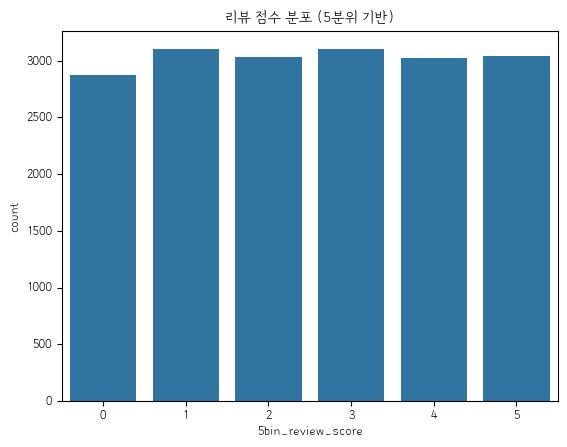

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm, rc

font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_prop = fm.FontProperties(fname=font_path)
rc('font', family=font_prop.get_name())

sns.countplot(x='5bin_review_score', data=df_review)
plt.title('리뷰 점수 분포 (5분위 기반)')
plt.show()


In [32]:
# 별점은 어차피 같음
import pandas as pd

rating_old =  pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수.csv')
rating_new = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0502.csv')
print(rating_old.columns.tolist())
print(rating_new.columns.tolist())
rating_old = rating_old[['상가업소번호', 'rating_score','floor_score', 'parking_score']]
rating_new = rating_new.merge(rating_old, on = '상가업소번호',how = 'left')
rating_new.head(3)

rating_new.to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0502.csv', encoding = 'utf-8-sig',index = False)

['상가업소번호', 'period_score', 'rating_score', 'review_score', '5bin_review_score', 'sales_score_total', 'sales_score_grouped', 'floor_score', 'parking_score']
['상가업소번호', 'period_score', '5bin_review_score', 'review_score']
